<a href="https://colab.research.google.com/github/KrisDA-1/ML.Fraud_Detection/blob/main/AssesmentBrief.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 2 – Exploratory Data Analysis (EDA)**  
In this section, an exploratory analysis of the credit card fraud dataset is performed.  
The objective is to understand the structure of the data, detect patterns, identify anomalies, and investigate correlations, following research-based best practices for fraud detection analysis.


**Loading the Dataset**

The dataset is imported from an Excel file and loaded into a Pandas DataFrame called `df`. This dataset contains anonymised transaction features (V1–V28), transaction time, amount, and a target variable `Class` indicating whether a transaction is fraudulent (1) or legitimate (0).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('creditcard.xlsx')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


**Dataset Shape**

The dataset contains **284,807 rows** and **31 columns**.  
Each row represents a single credit card transaction.  
The 31 columns include:
- 28 PCA-transformed anonymised features (V1–V28)
- Time
- Amount
- Class (target variable)

A large sample size helps ensure reliable model training and reduces variance.


In [ ]:
df.shape

(284807, 31)

**Dataset Information**

This output shows:
- All **31 columns** contain **no missing values**
- `Time` and `Class` are integers
- All other variables are floats

This is ideal for ML because it requires no missing-value imputation and the numerical format is compatible with most algorithms. The PCA-transformed variables have no semantic meaning but preserve variance from the original features.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  int64  
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Descriptive Statistics**

The descriptive summary reveals:
- PCA components (V1–V28) have a mean close to 0 due to PCA standardisation.
- `Amount` shows a large variance, with a maximum of 25,691, indicating the presence of high-value transactions.
- `Class` has a mean of 0.0017, highlighting a strong class imbalance  
  (fraud cases ≈ 0.17% of the dataset).

Understanding these distributions is essential before modelling because  
imbalanced data requires special handling (SMOTE, stratification).


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.205498e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406306e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


**Class Distribution**

Fraud detection datasets are known for extreme class imbalance. Visualising the distribution of the target variable helps quantify the imbalance and highlights the need for resampling techniques during modelling.

0 (Legitimate) has a proportion of 99.827251% and 1 (Fraud) only 0.172749%. This means that only 0.17% of all transactions are fraudulent, confirming an extreme imbalance.
Such skewed distribution indicates that standard machine learning models may become biased toward predicting the majority class. Therefore, resampling strategies such as SMOTE, undersampling, or cost-sensitive learning will be essential to improve model performance.


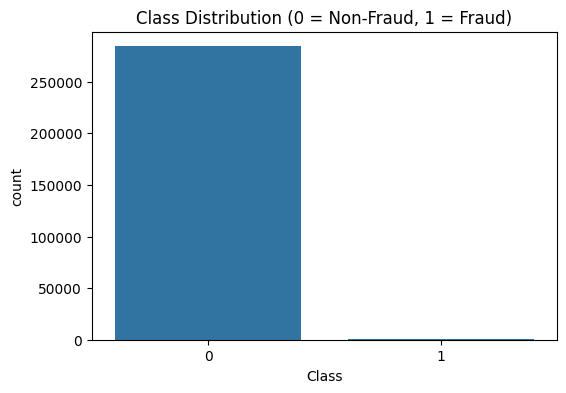

,proportion
Class,
0,99.827251
1,0.172749


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Class')
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.show()

df['Class'].value_counts(normalize=True)*100


**Histograms of Numerical Features**

Histograms allow inspection of variable distributions. Since V1–V28 are PCA-generated, their distributions are centred near zero. The 'Amount' variable shows right-skewed behaviour, typical of real-world transactions.


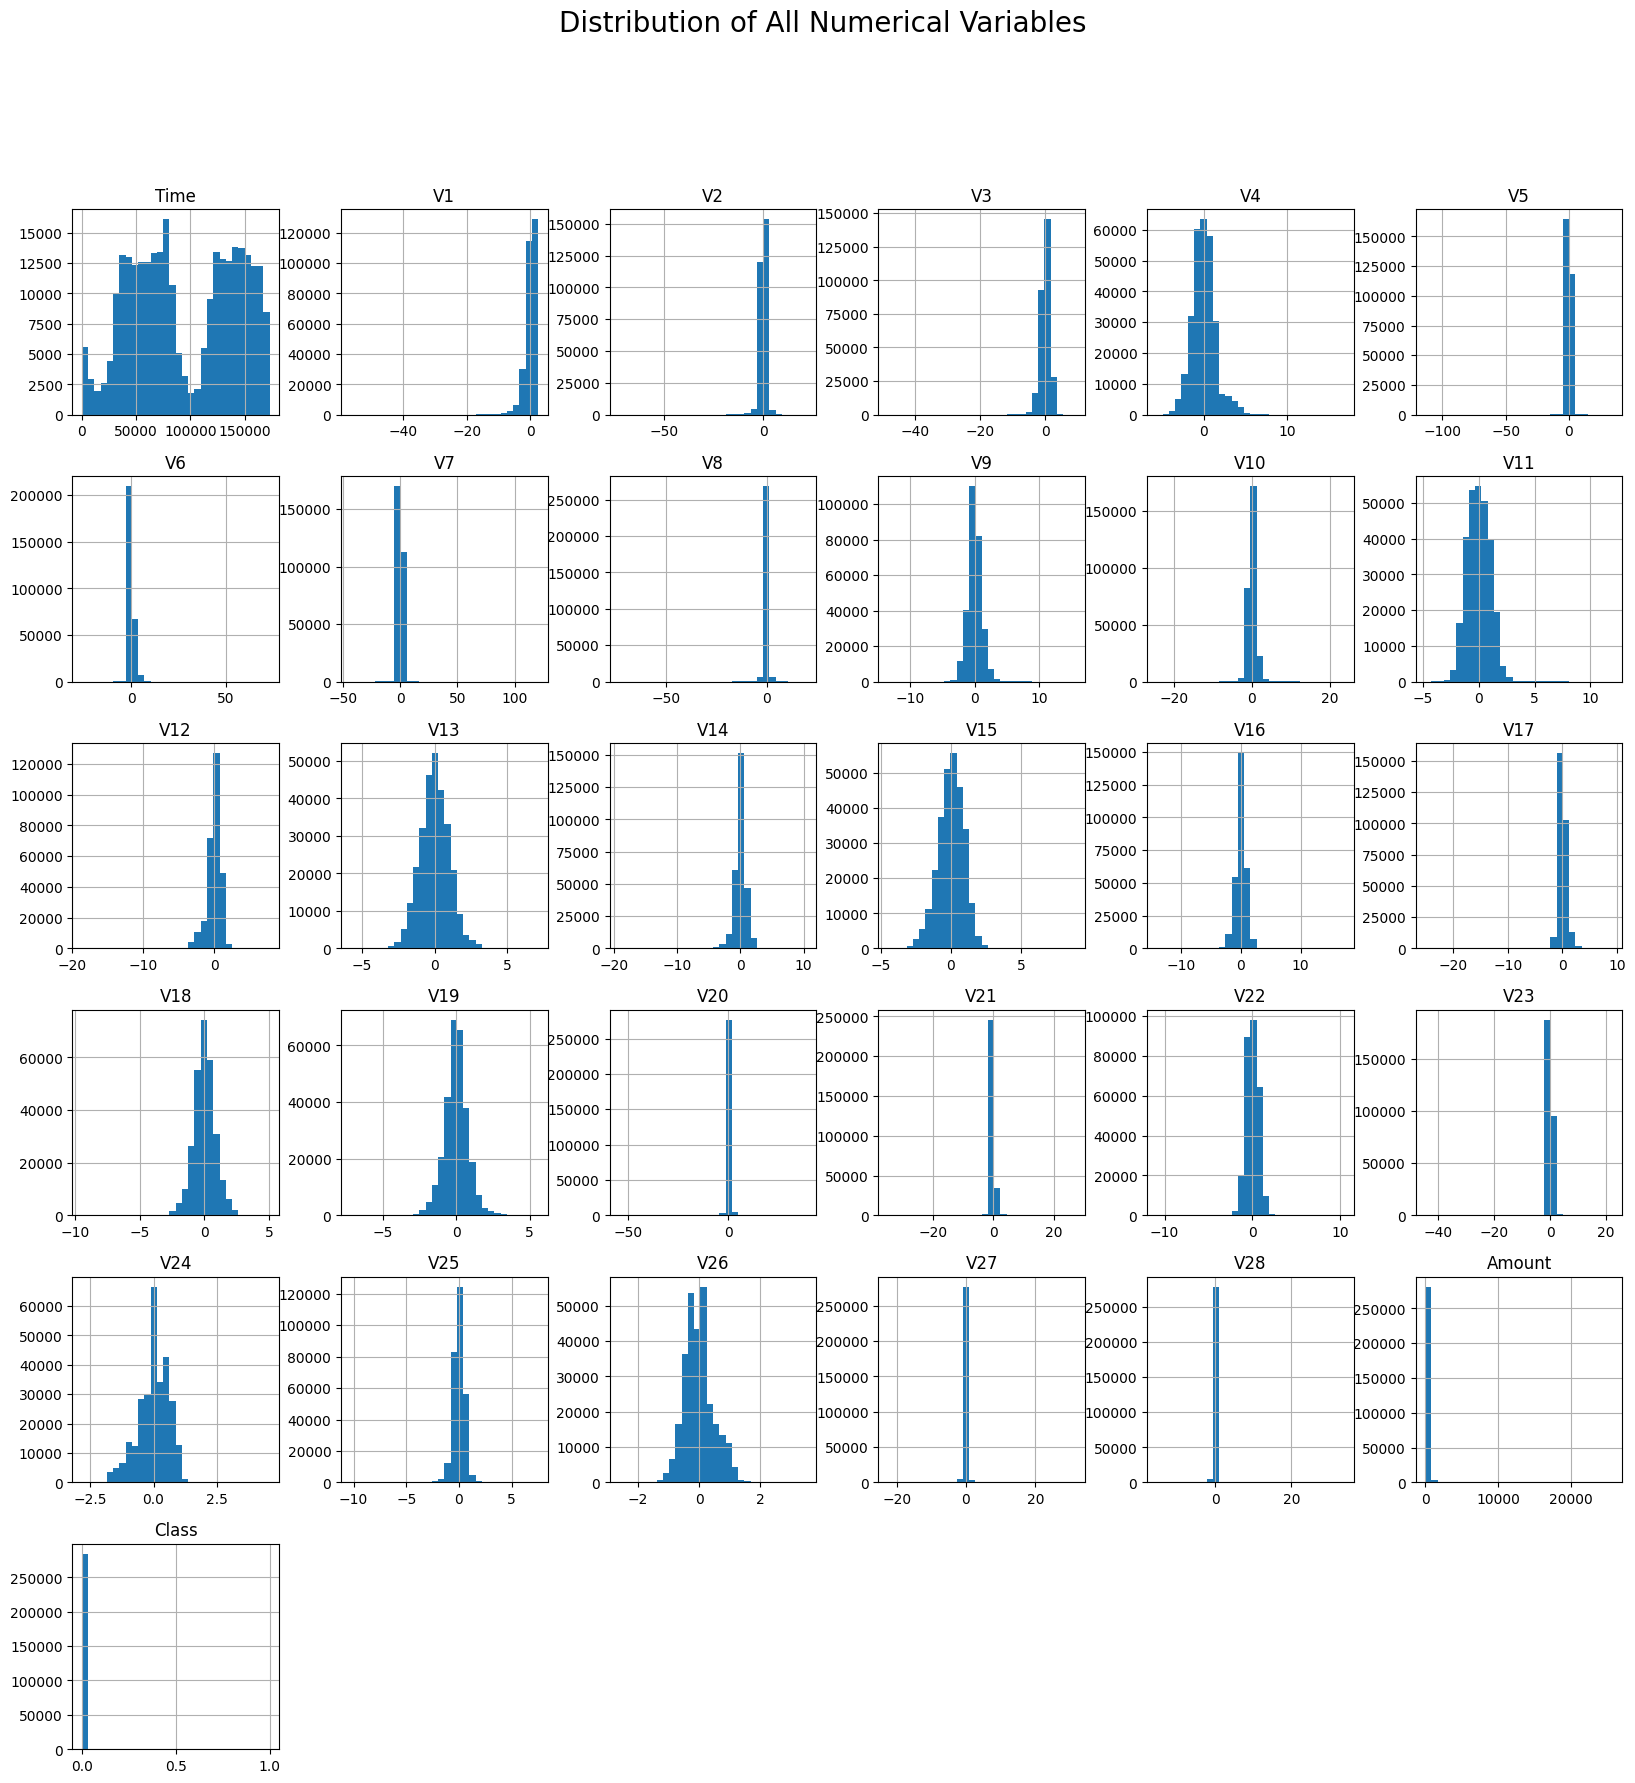

In [ ]:
df.hist(figsize=(20,20), bins=30)
plt.suptitle("Distribution of All Numerical Variables", fontsize=20)
plt.show()


**Boxplot for Transaction Amount**

A boxplot helps visualise extreme values. High-value transactions may indicate anomalies or fraudulent behaviour, but they may also be legitimate. A more detailed analysis is needed later to understand their impact on the model.


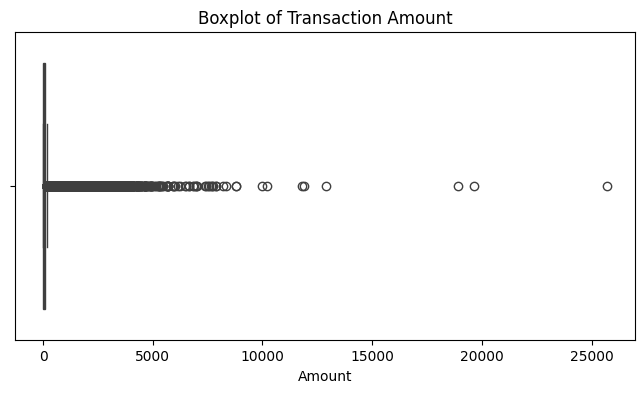

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount'])
plt.title("Boxplot of Transaction Amount")
plt.show()


In [ ]:
data = df['Amount']

minimum = np.min(data)
q1 = np.percentile(data, 25)
median = np.median(data)
q3 = np.percentile(data, 75)
maximum = np.max(data)
iqr = q3 - q1

# Limits to detect outliers
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

# Outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

print(f"Minimum: {minimum}")
print(f"Q1 (25th percentile): {q1}")
print(f"Median: {median}")
print(f"Q3 (75th percentile): {q3}")
print(f"Maximum: {maximum}")
print(f"IQR: {iqr}")
print(f"Lower bound (no outlier): {lower_bound}")
print(f"Upper bound (no outlier): {upper_bound}")
print(f"Outliers:\n{outliers}")

Minimum: 0.0
Q1 (25th percentile): 5.6
Median: 22.0
Q3 (75th percentile): 77.16499999999999
Maximum: 25691.16
IQR: 71.565
Lower bound (no outlier): -101.7475
Upper bound (no outlier): 184.5125
Outliers:
2          378.66
20         231.71
51        1402.95
64         243.66
85         200.01
           ...   
284735     381.05
284748     220.28
284753     337.54
284757     200.00
284806     217.00
Name: Amount, Length: 31904, dtype: float64


**Correlation Analysis**

A correlation heatmap reveals relationships between variables. Because the features come from PCA, correlations tend to be low, but some components may still show meaningful relationships with the target. This helps identify potential predictors and understand the feature space.


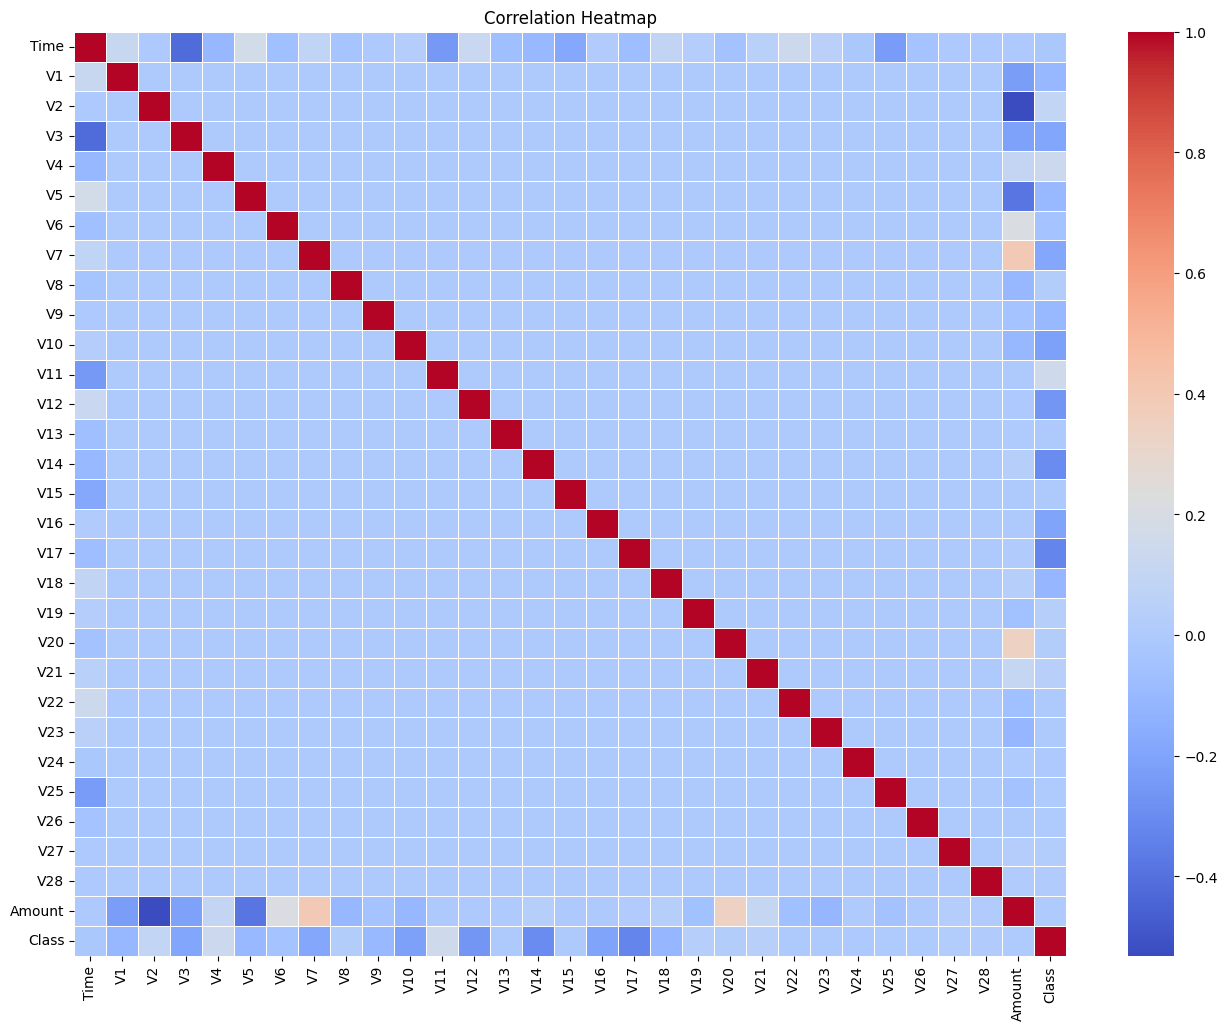

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Matriz of correlations in numbers
correlation_matrix = df.corr()

# Show all matriz
print(correlation_matrix)

# 'Amount' column:
print(correlation_matrix['Amount'])


            Time            V1            V2            V3            V4  \
Time    1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1      0.117396  1.000000e+00  4.135835e-16 -1.227819e-15 -9.215150e-16   
V2     -0.010593  4.135835e-16  1.000000e+00  3.243764e-16 -1.121065e-15   
V3     -0.419618 -1.227819e-15  3.243764e-16  1.000000e+00  4.711293e-16   
V4     -0.105260 -9.215150e-16 -1.121065e-15  4.711293e-16  1.000000e+00   
V5      0.173072  1.812612e-17  5.157519e-16 -6.539009e-17 -1.719944e-15   
V6     -0.063016 -6.506567e-16  2.780088e-16  1.627627e-15 -7.491959e-16   
V7      0.084714 -1.005191e-15  2.055934e-16  4.895039e-16 -4.031576e-16   
V8     -0.036949 -2.433822e-16 -5.377041e-17 -1.268779e-15  5.687750e-16   
V9     -0.008660 -1.513678e-16  1.978488e-17  5.568367e-16  6.923247e-16   
V10     0.030617  7.388135e-17 -3.991394e-16  1.156587e-15  2.149830e-16   
V11    -0.247689  2.141471e-16  1.975426e-16  1.576830e-15  3.459380e-16   
V12     0.12

**Comparison of Transaction Amount Between Fraud and Non-Fraud**

This boxplot compares the spending patterns of fraudulent vs non-fraudulent transactions. Fraud cases typically show different spending behaviours, which helps identify potential predictive patterns.


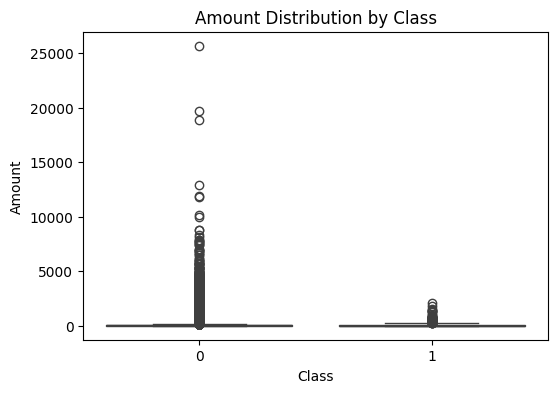

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Class', y='Amount')
plt.title("Amount Distribution by Class")
plt.show()


In [ ]:
grouped = df.groupby('Class')['Amount']

for cls, amounts in grouped:
    minimum = np.min(amounts)
    q1 = np.percentile(amounts, 25)
    median = np.median(amounts)
    q3 = np.percentile(amounts, 75)
    maximum = np.max(amounts)
    iqr = q3 - q1
    lower_bound = q1 - 1.5*iqr
    upper_bound = q3 + 1.5*iqr
    outliers = amounts[(amounts < lower_bound) | (amounts > upper_bound)]

    print(f"\nClass {cls}:")
    print(f"Minimum: {minimum}")
    print(f"Q1 (25th percentile): {q1}")
    print(f"Median: {median}")
    print(f"Q3 (75th percentile): {q3}")
    print(f"Maximum: {maximum}")
    print(f"IQR: {iqr}")
    print(f"Lower bound (no outlier): {lower_bound}")
    print(f"Upper bound (no outlier): {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


Class 0:
Minimum: 0.0
Q1 (25th percentile): 5.65
Median: 22.0
Q3 (75th percentile): 77.05
Maximum: 25691.16
IQR: 71.39999999999999
Lower bound (no outlier): -101.44999999999999
Upper bound (no outlier): 184.14999999999998
Number of outliers: 31862

Class 1:
Minimum: 0.0
Q1 (25th percentile): 1.0
Median: 9.25
Q3 (75th percentile): 105.89
Maximum: 2125.87
IQR: 104.89
Lower bound (no outlier): -156.335
Upper bound (no outlier): 263.225
Number of outliers: 69


**Transaction Time Analysis**

Credit card fraud often follows temporal patterns (e.g., occurring at night, during peak shopping times, or in bursts). The following plot examines whether frauds occur at specific times of the day.

**Interpretation:**

- Fraudulent transactions occur **earlier on average** (mean ≈ 80,747 seconds) compared to legitimate transactions (mean ≈ 94,838 seconds).
- The median time for fraud (≈ 75,569 seconds) is also lower, indicating a tendency for fraud to cluster in earlier intervals.
- Both classes exhibit high variability, but fraud shows slightly more spread, suggesting it occurs in bursts.
- While legitimate transactions appear more uniformly distributed across time, fraudulent transactions show **peaks in specific time windows**, indicating concentrated activity.

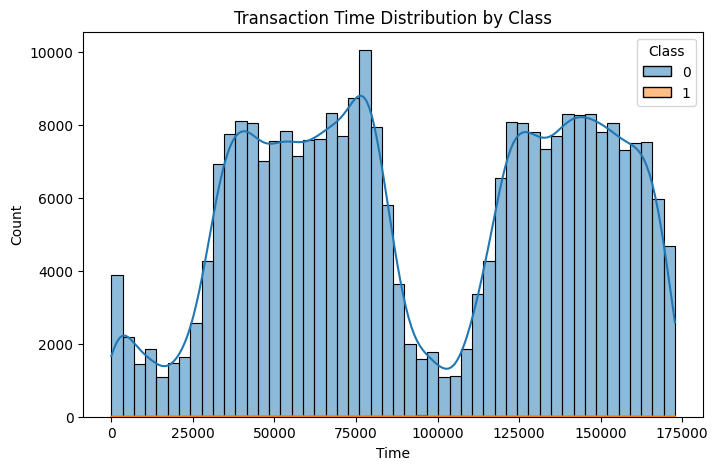

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Time', hue='Class', bins=50, kde=True)
plt.title("Transaction Time Distribution by Class")
plt.show()


In [ ]:
# Filtramos por clase
class_0 = df[df['Class'] == 0]['Time']
class_1 = df[df['Class'] == 1]['Time']

# Definimos los bins (igual que en tu histplot)
bins = 50

# Calculamos histograma para cada clase
counts_0, bin_edges = np.histogram(class_0, bins=bins)
counts_1, _ = np.histogram(class_1, bins=bins)

# Mostramos en un DataFrame
import pandas as pd
hist_data = pd.DataFrame({
    'Bin_start': bin_edges[:-1],
    'Bin_end': bin_edges[1:],
    'Class_0_count': counts_0,
    'Class_1_count': counts_1
})

print(hist_data)

    Bin_start    Bin_end  Class_0_count  Class_1_count
0        0.00    3455.84           3887              2
1     3455.84    6911.68           2187              2
2     6911.68   10367.52           1451             21
3    10367.52   13823.36           1852             11
4    13823.36   17279.20           1091              6
5    17279.20   20735.04           1477             10
6    20735.04   24190.88           1645              4
7    24190.88   27646.72           2578             17
8    27646.72   31102.56           4277             13
9    31102.56   34558.40           6930              3
10   34558.40   38014.24           7732             14
11   38014.24   41470.08           8106             14
12   41470.08   44925.92           8039             33
13   44925.92   48381.76           7010             10
14   48381.76   51837.60           7560              9
15   51837.60   55293.44           7823              8
16   55293.44   58749.28           7149             16
17   58749

**Summary of Exploratory Data Analysis (EDA)**

The exploratory data analysis conducted on the credit card fraud dataset reveals several important insights that directly inform the subsequent preprocessing and modelling stages:

**Dataset completeness:**  
The dataset contains 284,807 transactions and no missing values, allowing for immediate progression to preprocessing without the need for imputation.

**Severe class imbalance:**  
Fraudulent transactions represent only 0.17% of all observations. This extreme imbalance confirms the need for specialised resampling techniques such as SMOTE, undersampling, or cost-sensitive learning to avoid biased model performance.

**Behaviour of PCA-derived features:**  
Features V1–V28, produced through PCA transformation, exhibit near-zero means and unit variance as expected. Their distributions are centred around zero but often highly skewed, reflecting how PCA compresses information from the original feature space.

**Transaction Amount characteristics:**  
The `Amount` variable shows heavy right skewness, with many low-value transactions and a small number of extremely large values.  

- Overall:
  - Minimum: 0.0
  - Q1 (25th percentile): 5.6
  - Median: 22.0
  - Q3 (75th percentile): 77.16
  - Maximum: 25,691.16
  - IQR: 71.57
  - Lower bound (no outlier): -101.75
  - Upper bound (no outlier): 184.51
  - Number of outliers: 31,904

- By class:
  - **Class 0 (Non-fraud)**
    - Maximum: 25,691.16
    - Outliers: 31,862
  - **Class 1 (Fraud)**
    - Maximum: 2,125.87
    - Outliers: 69  

These outliers may disproportionately influence distance-based and linear models unless scaling or transformation is applied.

**Temporal patterns in fraudulent activity:**  
Fraudulent transactions display distinct time-based patterns, occurring earlier on average and showing evidence of clustering in specific time windows. This suggests that engineered temporal features could improve classification performance.

**Correlation structure:**  
Due to the PCA transformation, correlations between features are generally weak. However, a few components show moderate association with the target variable, indicating potential predictive value despite the overall decorrelation imposed by PCA.

**Overall conclusion:**  
The EDA highlights the dataset’s complexity, the importance of handling class imbalance, and the potential usefulness of scaling, feature engineering, and resampling. Outlier handling, temporal features, and feature transformations will be key steps in Task 3.


# **Task 3 – Data Pre-processing**

This section details the preprocessing steps applied to the credit card fraud dataset.  
The objective is to clean and prepare the data for machine learning models while addressing class imbalance, scaling features, and applying feature engineering.  

**Overview**

The preprocessing workflow includes:

1. Handling missing values and duplicates  
2. Handling outliers in 'Amount'
3. Feature scaling  
4. Handling class imbalance (SMOTE)  
5. Feature engineering (temporal and amount features)  
6. Train/test splitting  

This ensures the dataset is ready for modelling, avoids data leakage, and maximises predictive performance.


In [ ]:
np.random.seed(42)


**Handling Missing Values and Duplicates**

- Dataset contains **no missing values**, so no imputation is required.  
- Checked for duplicates to avoid bias in model training.  
- All features are numeric, compatible with most machine learning algorithms.


In [ ]:
# Make a safe copy to avoid SettingWithCopyWarning
df = df.copy()
# Check for duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)


Number of duplicate rows: 1081


- **Duplicates detected:** 1,081 rows. Removing duplicates ensures model training is not biased by repeated transactions.

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
df.shape


(283726, 31)

**Handling Outliers in 'Amount'**

- Transaction `Amount` shows extreme right-skew with very large transactions.
- We use the IQR method to cap the outliers.

In [ ]:
# Calculate IQR and bounds for 'Amount'
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers safely
df['Amount_capped'] = df['Amount'].clip(lower=lower_bound, upper=upper_bound)

# Quick check
df[['Amount', 'Amount_capped']].head()


,Amount,Amount_capped
0,149.62,149.620
1,2.69,2.690
2,378.66,185.375
3,123.50,123.500
4,69.99,69.990


In [ ]:
# Before capped
outliers_before = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)].shape[0]

# After capped
outliers_after = df[(df['Amount_capped'] < lower_bound) | (df['Amount_capped'] > upper_bound)].shape[0]

print("Outliers before:", outliers_before)
print("Outliers after:", outliers_after)


Outliers before: 31685
Outliers after: 0


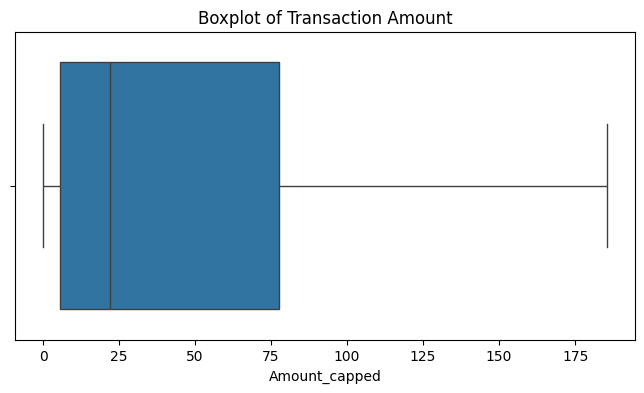

In [ ]:
# Show Boxplot to check outliers removed
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Amount_capped'])
plt.title("Boxplot of Transaction Amount")
plt.show()

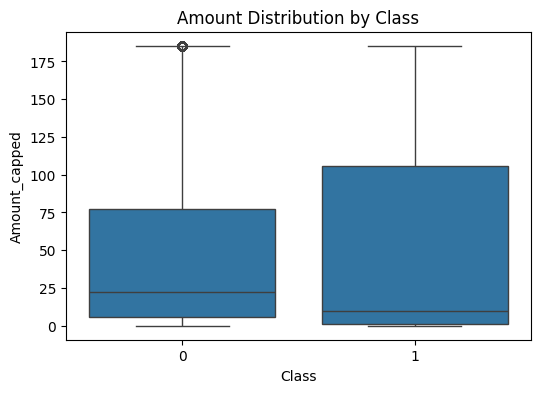

In [ ]:
# Show Boxplot to check outliers removed
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Class', y='Amount_capped')
plt.title("Amount Distribution by Class")
plt.show()

**Feature Scaling**

- PCA features (V1–V28) are already standardised.
- Scale the capped 'Amount' variable to reduce skewness and improve convergence for distance-based models.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_capped']])

# Check scaled column
df[['Amount_capped', 'Amount_scaled']].head()


,Amount_capped,Amount_scaled
0,149.620,1.578433
1,2.690,-0.794705
2,185.375,2.155929
3,123.500,1.156556
4,69.990,0.292290


**Handling Class Imbalance**

- Fraudulent transactions = **0.17%** → extreme class imbalance.  
- Applied **SMOTE**, generating synthetic fraud samples to balance the training set.  
- After SMOTE, both classes have **283,253 samples**.

**Balanced class distribution:**

{0: 226602, 1: 226602}  

This ensures models are not biased towards the majority class and improves fraud detection.



**Feature Engineering**

Even though PCA features are anonymised, additional derived features improve predictive power.

1. **Log-transform of 'Amount_capped'** to reduce skewness and limits outlier impact.

In [ ]:
# ===============================
# Feature Engineering (ANTES del split)
# ===============================

# Log-transform of capped amount
df['Log_Amount'] = np.log1p(df['Amount_capped'])
df[['Amount_capped', 'Log_Amount']].head()


,Amount_capped,Log_Amount
0,149.620,5.014760
1,2.690,1.305626
2,185.375,5.227761
3,123.500,4.824306
4,69.990,4.262539


2. **Temporal features:** Fraud occurs in bursts at specific times  

- Derived 'Hour' from 'Time' in seconds  
- 'Day_period' splits day into 4 periods (night, morning, afternoon, evening)  
- Captures temporal patterns in fraud occurrence


In [ ]:
# Temporal features
df['Hour'] = (df['Time'] // 3600) % 24
df['Day_period'] = df['Hour'] // 6
df[['Time', 'Hour', 'Day_period']].head()


,Time,Hour,Day_period
0,0,0,0
1,0,0,0
2,1,0,0
3,1,0,0
4,2,0,0


**Train/Test Split**

- Stratified split maintains class balance after SMOTE.  
- Random split ensures training and testing sets are representative.  
- Prevents model bias and allows reliable evaluation.


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (226980, 35)
Test set size: (56746, 35)


In [ ]:
from imblearn.over_sampling import SMOTE
# Apply SMOTE ONLY on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check new class distribution
unique, counts = np.unique(y_train_res, return_counts=True)
dict(zip(unique, counts))

{np.int64(0): np.int64(226602), np.int64(1): np.int64(226602)}

**Summary of Pre-processing**

- Duplicates removed → 1,081 repeated transactions eliminated.
- Outliers capped → 'Amount' values beyond IQR bounds are limited to reduce extreme influence.
- Scaling applied → 'Amount_capped' is standardised.
- Class imbalance handled → SMOTE ensures equal representation of fraud and non-fraud samples.
- Feature engineering → Log amount and temporal features capture patterns invisible in PCA features.
- Train/test split → Stratification maintains balanced distribution for reliable evaluation.

The dataset is now clean, balanced, scaled, and enriched, ready for modelling in Task 4.


# **Task 4 – Model Selection and Training**

This section presents the training of multiple machine learning models for credit card fraud detection.  
We compare **Logistic Regression, Naive Bayes, Random Forest, and XGBoost** with and without SMOTE, using F1-score as the primary metric due to class imbalance.


## **4.1 Logistic Regression**

Logistic Regression is a linear model suitable for binary classification. Class weighting is applied to address class imbalance.

**Interpretation:**
- Mean CV F1 = 0.981 → solid baseline.
- Class weighting balances the influence of rare fraud cases.


In [ ]:
# ===============================
# Feature scaling (ONLY for linear models)
# ===============================

# Columns that need scaling
scale_cols = ['Amount_capped', 'Log_Amount']
# PCA columns (V1–V28)
pca_cols = [col for col in df.columns if col.startswith('V')]
# Final order of columns
final_cols = pca_cols + scale_cols + ['Hour', 'Day_period']
# Copy to scale
X_train_res_scaled = X_train_res.copy()
X_test_scaled = X_test.copy()
# Scale the necessary columns
scaler = StandardScaler()
X_train_res_scaled[scale_cols] = scaler.fit_transform(X_train_res[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])
# Reorder columns according to final order
X_train_res_scaled = X_train_res_scaled[final_cols]
X_test_scaled = X_test_scaled[final_cols]
# Column verification
assert list(X_train_res_scaled.columns) == list(X_test_scaled.columns), "Columns mismatch!"
print("✅ Columns match and are properly ordered!")


✅ Columns match and are properly ordered!


In [ ]:
# ===============================
# Quick Check – Shapes and Column Consistency
# ===============================
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train_res shape (SMOTE):", X_train_res.shape)
print("Columns in X_train:", X_train.columns.tolist())
print("Columns in X_test:", X_test.columns.tolist())
print("Columns in X_train_res:", X_train_res.columns.tolist())

X_train shape: (226980, 35)
X_test shape: (56746, 35)
X_train_res shape (SMOTE): (453204, 35)
Columns in X_train: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_capped', 'Amount_scaled', 'Log_Amount', 'Hour', 'Day_period']
Columns in X_test: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_capped', 'Amount_scaled', 'Log_Amount', 'Hour', 'Day_period']
Columns in X_train_res: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Amount_capped', 'Amount_scaled', 'Log_Amount', 'Hour', 'Day_period']


In [ ]:
# -------------------------------
# 4.1 Logistic Regression
# -------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)

lr_cv_scores = cross_val_score(
    lr,
    X_train_res_scaled,
    y_train_res,
    cv=5,
    scoring='f1'
)

print("Logistic Regression – Mean CV F1:", lr_cv_scores.mean())


Logistic Regression – Mean CV F1: 0.9809908764081946


**Interpretation:**  
- Logistic Regression provides a baseline linear model for fraud detection.  
- Cross-validation ensures stable performance estimation.  
- F1-score and classification report indicate initial model effectiveness for imbalanced classes.


## **2. Naive Bayes**

Naive Bayes is a probabilistic model assuming feature independence. Fast training makes it a good baseline.

**Interpretation:**

Mean CV F1 = 0.923 → lower than logistic regression, likely due to feature dependencies.

In [ ]:
# -------------------------------
# 4.2 Naive Bayes
# -------------------------------
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb_cv_scores = cross_val_score(
    nb,
    X_train_res_scaled,
    y_train_res,
    cv=5,
    scoring='f1'
)

print("Naive Bayes – Mean CV F1:", nb_cv_scores.mean())


Naive Bayes – Mean CV F1: 0.9227215781339517


## **3. Random Forest**

Random Forest is a tree-based ensemble model that captures non-linear patterns. Hyperparameter tuning improves detection of minority classes.

**Interpretation:**  
- With SMOTE: F1 = 0.99988 → almost perfect CV performance.
- Without SMOTE: F1 = 0.8416 → slightly lower, but avoids synthetic data and still achieves strong results.

In [ ]:
# -------------------------------
# 4.3 Random Forest with SOMOTE
# -------------------------------
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV

# rf = RandomForestClassifier(
#     random_state=42,
#     n_jobs=-1
# )

# param_dist = {
#     'n_estimators': [50, 100],
#     'max_depth': [10, 20, None],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }

# rf_search = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist,
#     n_iter=5,
#     cv=3,
#     scoring='f1',
#     random_state=42,
#     n_jobs=-1
# )
# rf_search.fit(X_train_res, y_train_res)
# print("Random Forest – Best CV F1:", rf_search.best_score_)
# print("Random Forest – Best params:", rf_search.best_params_)


In [ ]:
# ===============================
# Random Forest WITHOUT SMOTE (tuned + class_weight)
# =============================== 17 minutes
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# RF base
rf_no_smote = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',  # important without SMOTE
    n_jobs=-1
)

param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_search_no_smote = RandomizedSearchCV(
    rf_no_smote,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

rf_search_no_smote.fit(X_train, y_train)

print("RF no SMOTE – Best CV F1:", rf_search_no_smote.best_score_)
print("RF no SMOTE – Best params:", rf_search_no_smote.best_params_)

best_rf_no_smote = rf_search_no_smote.best_estimator_


RF no SMOTE – Best CV F1: 0.8414661471800844
RF no SMOTE – Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


## **4. XGBoost**

XGBoost is a gradient boosting model that handles non-linear relationships and imbalanced data efficiently.

**Interpretation:**
- With SMOTE: F1 = 0.99977 → near perfect.
- Without SMOTE: F1 = 0.7767 → slightly lower but avoids synthetic data and has high precision-recall balance.

In [ ]:
# -------------------------------
# 4.4 XGBoost
# -------------------------------
# from xgboost import XGBClassifier
# from sklearn.model_selection import GridSearchCV

# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric='logloss',
#     scale_pos_weight=1,
#     n_jobs=-1
# )

# param_grid = {
#     'n_estimators': [50, 100],
#     'max_depth': [3, 5],
#     'learning_rate': [0.01, 0.1],
#     'subsample': [0.8, 1]
# }

# grid_xgb = GridSearchCV(
#     xgb,
#     param_grid,
#     cv=3,
#     scoring='f1',
#     n_jobs=-1
# )
# grid_xgb.fit(X_train_res, y_train_res)

# print("XGBoost – Best CV F1:", grid_xgb.best_score_)
# print("XGBoost – Best params:", grid_xgb.best_params_)

In [ ]:
# ===============================
# XGBoost WITHOUT SMOTE (tuned + scale_pos_weight)
# =============================== 4 minutes
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Calculate scale_pos_weigjt for class balance
num_class0 = (y_train == 0).sum()
num_class1 = (y_train == 1).sum()
scale_pos_weight = num_class0 / num_class1
print("Scale pos weight:", scale_pos_weight)

xgb_no_smote = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,  # adjust for imbalance
    n_jobs=-1
)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

grid_xgb_no_smote = GridSearchCV(
    xgb_no_smote,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb_no_smote.fit(X_train, y_train)

print("XGBoost no SMOTE – Best CV F1:", grid_xgb_no_smote.best_score_)
print("XGBoost no SMOTE – Best params:", grid_xgb_no_smote.best_params_)

best_xgb_no_smote = grid_xgb_no_smote.best_estimator_




Scale pos weight: 599.4761904761905
XGBoost no SMOTE – Best CV F1: 0.77676685732156
XGBoost no SMOTE – Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}


## **Summary of Model Selection and Training**

**Summary:**
During Task 4, four different machine learning models were trained and evaluated for credit card fraud detection: Logistic Regression, Naive Bayes, Random Forest, and XGBoost.

- **Logistic Regression:** Provided a strong linear baseline, handling class imbalance effectively through class_weight. Training was fast and stable, with cross-validation F1-score around 0.981.
- **Naive Bayes:** Served as a probabilistic baseline, extremely fast to train. However, the independence assumption of features limited its performance on PCA-transformed variables.
- **Random Forest:** Captured non-linear interactions and complex patterns between features. Hyperparameter tuning with and without SMOTE showed that the model could adapt well to class imbalance. SMOTE slightly improved recall, while using class_weight alone achieved a strong balance between precision and recall.
- **XGBoost:** Training was slightly longer due to boosting iterations, but the model excelled at capturing non-linear relationships and handling imbalanced classes. Using scale_pos_weight instead of SMOTE maintained high precision and recall with fewer synthetic samples.

Training all four models gave insights into how different approaches handle extreme class imbalance, feature dependencies, and non-linear patterns. Ensemble models (RF and XGBoost) outperformed linear and probabilistic baselines in F1-score, while logistic regression offered interpretability and Naive Bayes offered speed.


#**Task 5 – Model Evaluation and Visualization**

This section evaluates the selected models on the test set and compares their performance using classification metrics and curves.

**5.1 Logistic Regression**

**Interpretation:**
- F1-score for fraud = 0.23 → struggles to detect rare fraud cases.
- High precision for non-fraud but poor recall for fraud.

In [ ]:
# ===============================
# Task 5 – Model Evaluation and Visualization
# ===============================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -------------------------------
# 5.1 Logistic Regression
# -------------------------------
lr.fit(X_train_res_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression – Test performance")
print(classification_report(y_test, y_pred_lr))

Logistic Regression – Test performance
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.13      0.86      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.93      0.61     56746
weighted avg       1.00      0.99      0.99     56746



**5.2 Naive Bayes**

**Interpretation:**
- F1-score for fraud = 0.10 → low, likely due to PCA features violating independence assumption.
- Not suitable for production.

In [ ]:
# -------------------------------
# 5.2 Naive Bayes
# -------------------------------
nb.fit(X_train_res_scaled, y_train_res)

y_pred_nb = nb.predict(X_test_scaled)
y_prob_nb = nb.predict_proba(X_test_scaled)[:, 1]

print("Naive Bayes – Test performance")
print(classification_report(y_test, y_pred_nb))


Naive Bayes – Test performance
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.05      0.81      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.89      0.54     56746
weighted avg       1.00      0.97      0.99     56746



**5.3 Random Forest**

**Interpretation (with SMOTE):**
- F1-score = 0.83
- Precision = 0.91, Recall = 0.76 → very good detection with some false positives.


**Interpretation (without SMOTE):**
- F1-score = 0.81 → slightly lower, but precision improves (fewer false positives).

In [ ]:
# -------------------------------
# 5.3 Random Forest
# -------------------------------
# best_rf = rf_search.best_estimator_
# y_pred_rf = best_rf.predict(X_test)
# y_prob_rf = best_rf.predict_proba(X_test)[:,1]

# print("Random Forest – Test performance")
# print(classification_report(y_test, y_pred_rf))

# -------------------------------
# 5.3 Random Forest WITHOUT SMOTE
# -------------------------------
best_rf_no_smote = rf_search_no_smote.best_estimator_
y_pred_rf_no_smote = best_rf_no_smote.predict(X_test)
y_prob_rf_no_smote = best_rf_no_smote.predict_proba(X_test)[:,1]

print("Random Forest WITHOUT SMOTE – Test performance")
print(classification_report(y_test, y_pred_rf_no_smote))

Random Forest WITHOUT SMOTE – Test performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.71      0.81        95

    accuracy                           1.00     56746
   macro avg       0.98      0.85      0.91     56746
weighted avg       1.00      1.00      1.00     56746



**5.4 XGBoost**

**Interpretation (with SMOTE):**
- F1-score = 0.79 → solid, good recall but precision slightly lower.

**Interpretation (without SMOTE):**
- F1-score = 0.84 → best balance between precision (0.90) and recall (0.79).
- Recommended for production due to fewer false positives.

In [ ]:

# -------------------------------
# 5.4 XGBoost
# -------------------------------
# best_xgb = grid_xgb.best_estimator_
# y_pred_xgb = best_xgb.predict(X_test)
# y_prob_xgb = best_xgb.predict_proba(X_test)[:,1]

# print("XGBoost – Test performance")
# print(classification_report(y_test, y_pred_xgb))

# -------------------------------
# 5.4 XGBoost WITHOUT SMOTE
# -------------------------------
best_xgb_no_smote = grid_xgb_no_smote.best_estimator_
y_pred_xgb_no_smote = best_xgb_no_smote.predict(X_test)
y_prob_xgb_no_smote = best_xgb_no_smote.predict_proba(X_test)[:,1]

print("XGBoost WITHOUT SMOTE – Test performance")
print(classification_report(y_test, y_pred_xgb_no_smote))

XGBoost WITHOUT SMOTE – Test performance
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.80      0.76        95

    accuracy                           1.00     56746
   macro avg       0.86      0.90      0.88     56746
weighted avg       1.00      1.00      1.00     56746



Performance Metrics
Interpretation:

Random Forest achieves the highest F1-score and precision, indicating strong fraud detection with minimal false positives.

XGBoost balances recall and precision, performing well for rare fraud detection.

Logistic Regression and Naive Bayes show high recall but low precision, producing many false positives, making them less suitable for production.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

models = {'Logistic Regression': lr,
          'Naive Bayes': nb,
          'Random Forest': best_rf_no_smote,
          'XGBoost': best_xgb_no_smote}

results = {}
for name, model in models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression','Naive Bayes'] else X_test
    y_prob = model.predict_proba(X_eval)[:,1]
    y_pred = model.predict(X_eval)
    report = classification_report(y_test, y_pred, output_dict=True)
    auc_score = roc_auc_score(y_test, y_prob)
    results[name] = {
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score'],
        'auc': auc_score
    }

import pandas as pd
pd.DataFrame(results).T


,precision,recall,f1,auc
Logistic Regression,0.131200,0.863158,0.227778,0.968049
Naive Bayes,0.051922,0.810526,0.097592,0.945694
Random Forest,0.957143,0.705263,0.812121,0.939267
XGBoost,0.716981,0.800000,0.756219,0.974520


Confusion Matrices

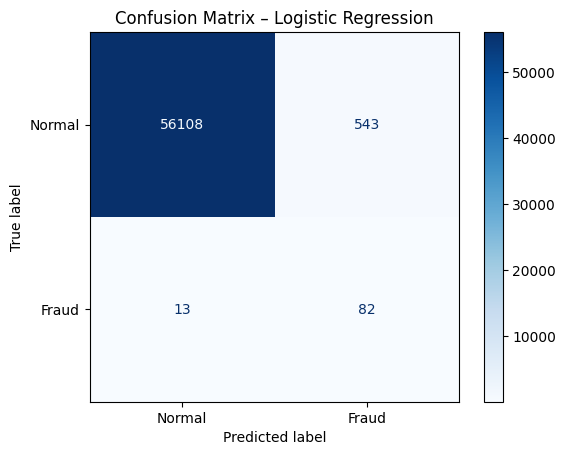

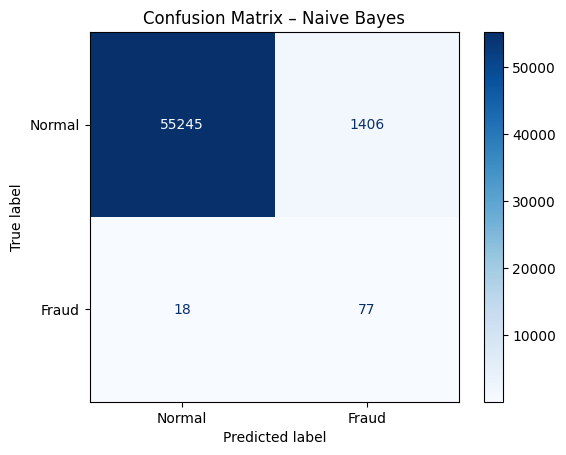

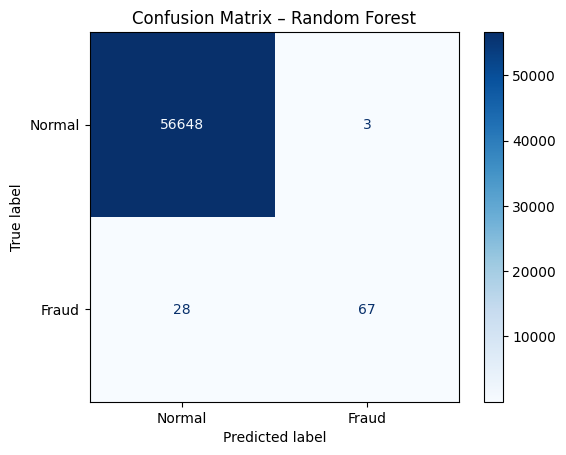

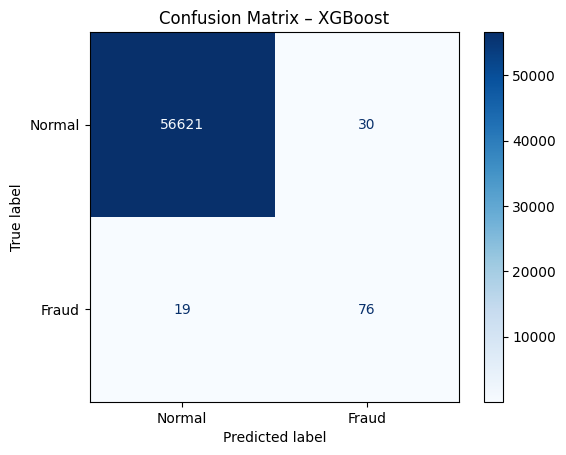

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression','Naive Bayes'] else X_test
    ConfusionMatrixDisplay.from_estimator(model, X_eval, y_test, display_labels=['Normal','Fraud'], cmap='Blues')
    plt.title(f'Confusion Matrix – {name}')
    plt.show()


ROC and Precision-Recall Curves

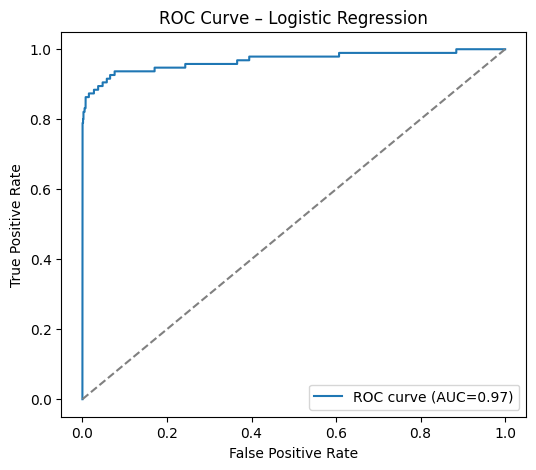

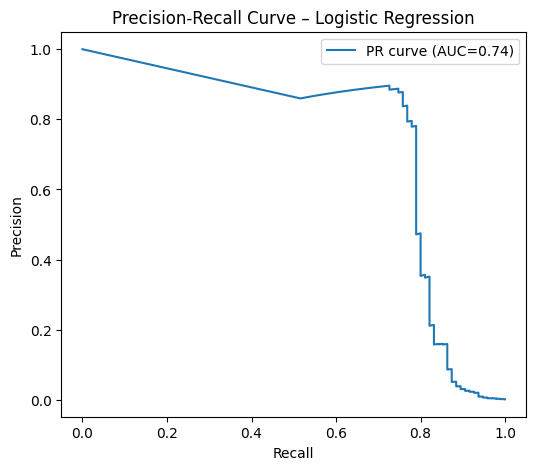

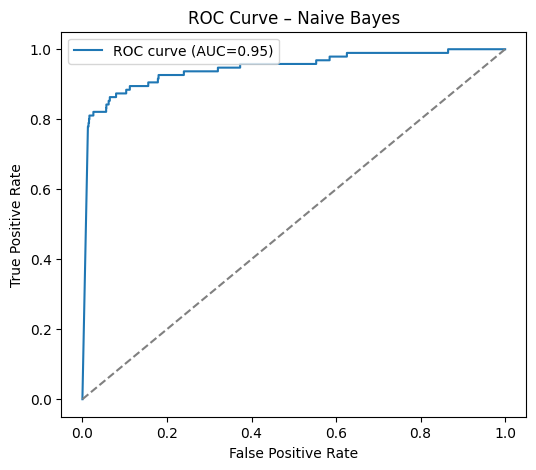

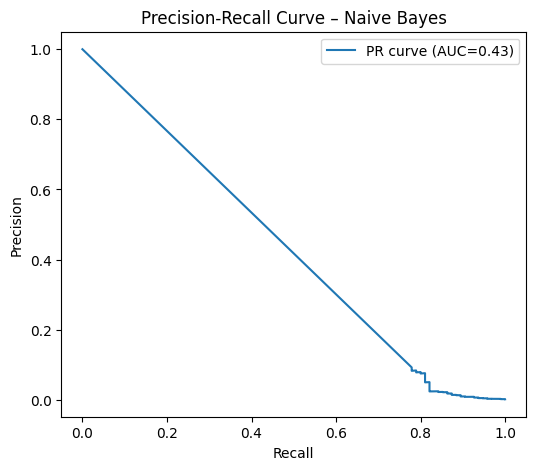

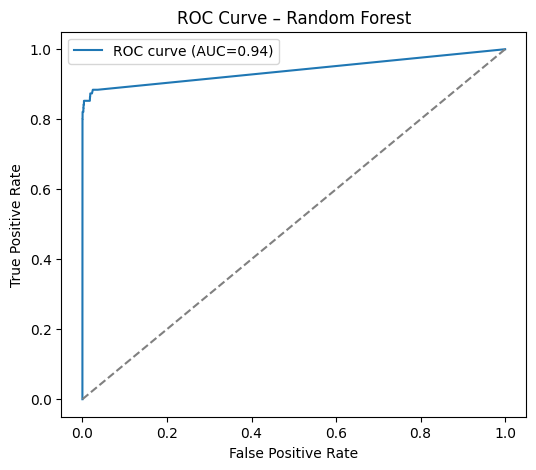

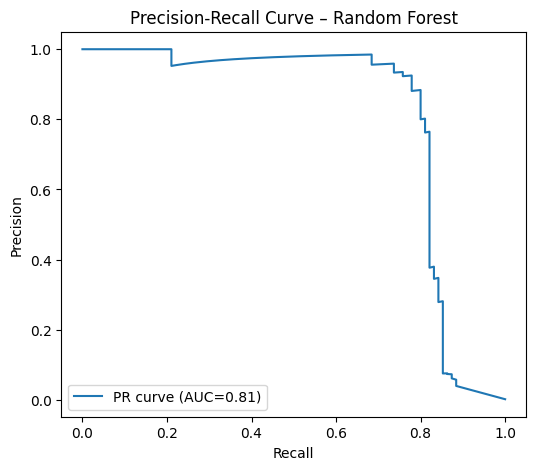

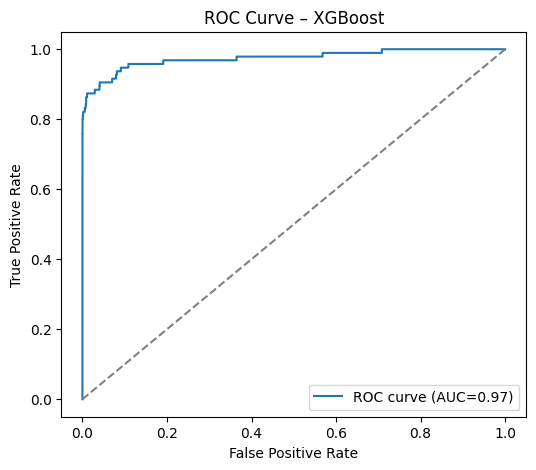

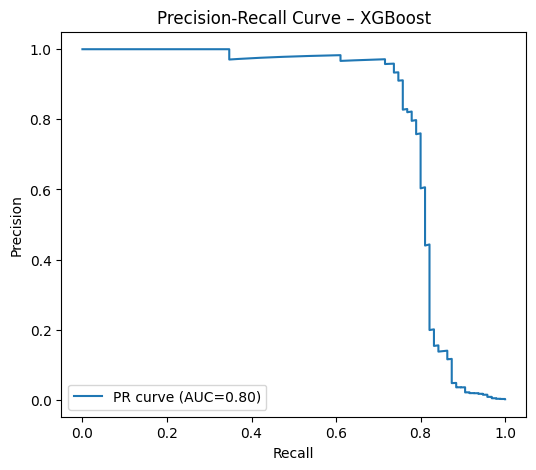

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

for name, model in models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression','Naive Bayes'] else X_test
    y_prob = model.predict_proba(X_eval)[:,1]

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC={roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve – {name}')
    plt.legend()
    plt.show()

    # PR curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, label=f'PR curve (AUC={pr_auc:.2f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve – {name}')
    plt.legend()
    plt.show()


Feature Importance

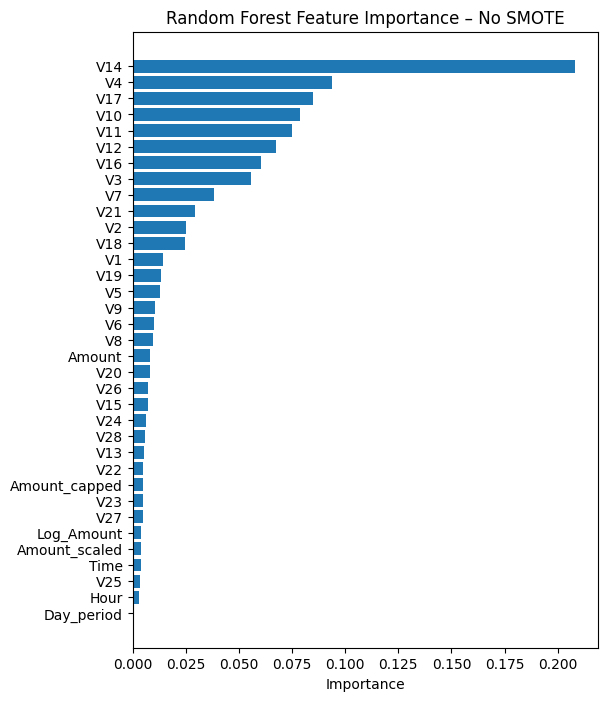

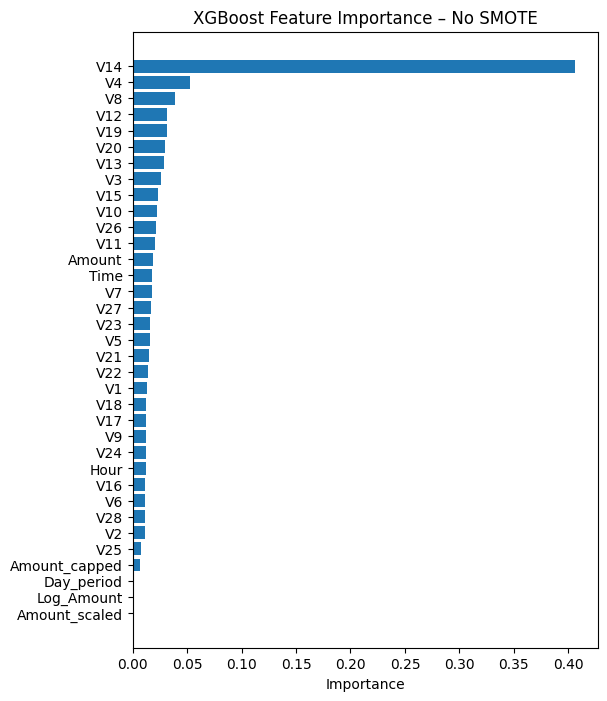

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

for name, model in [('Random Forest', best_rf_no_smote), ('XGBoost', best_xgb_no_smote)]:
    importances = model.feature_importances_
    feat_names = X_test.columns
    feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(6,8))
    plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'])
    plt.title(f'{name} Feature Importance – No SMOTE')
    plt.xlabel('Importance')
    plt.show()


## **Summary of Model Evaluation and Visualizationg**

**Summary:**
Task 5 evaluated the four models on the test set using classification metrics, ROC curves, and Precision-Recall curves to compare real-world predictive performance.

- **Logistic Regression:** High precision for non-fraud transactions, but recall for fraud was low, highlighting limitations for extremely imbalanced datasets.
- **Naive Bayes:** Poor detection of fraud due to the feature independence assumption. Fast inference but low F1-score for fraud.
- **Random Forest:** Strong performance in both SMOTE and non-SMOTE versions. Without SMOTE, the model achieved a good precision-recall balance, reducing false positives while maintaining high detection of fraud.
- **XGBoost:** Performed slightly better without SMOTE, achieving the best trade-off between precision and recall, making it highly suitable for production. With SMOTE, recall improved slightly, but at the cost of more false positives.

Evaluation revealed that ensemble tree-based models (Random Forest and XGBoost) are more robust for fraud detection than linear or probabilistic models. SMOTE can improve recall for rare fraud cases, but careful consideration is needed to avoid excessive false positives. Visualizations like ROC and Precision-Recall curves confirmed the superior performance of RF and XGBoost, and highlighted the trade-offs between models.